# Libraries and Data

In [ ]:
import geopandas as gpd
import branca.colormap as cm
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.cm as mpcm
import matplotlib.colors as mcolors
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.colors as mcolors
from matplotlib.colorbar import ColorbarBase
import numpy as np
import pandas as pd

In [ ]:


# Load the traffic volume GeoJSON
gdf = gpd.read_file("yearly_traffic_volume_layers_2602944522563934822.geojson")
print(gdf.shape)
gdf[["route_id", "street_name", "num_aadt", "num_lanes", "posted_speed", "nfc_name"]].head()


(1427, 19)


,route_id,street_name,num_aadt,num_lanes,posted_speed,nfc_name
0,802803,8 Mile Rd E,54905,4.0,40,Other principal arterial
1,802803,8 Mile Rd E,37940,4.0,40,Other principal arterial
2,802803,8 Mile Rd E,39725,4.0,40,Other principal arterial
3,1576405,I 94,126670,6.0,55,Interstate
4,1576405,I 94,119706,6.0,55,Interstate


## Traffic Density Processing

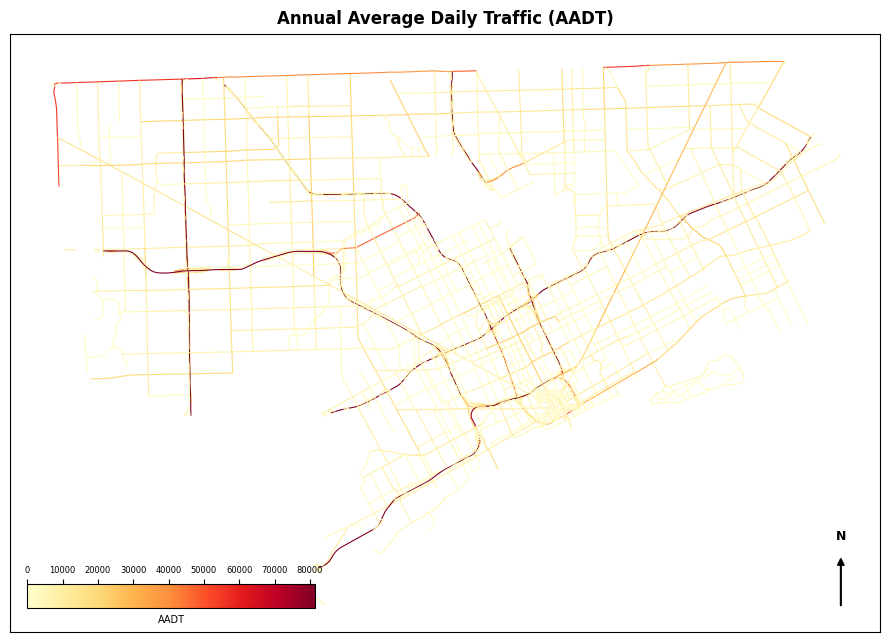

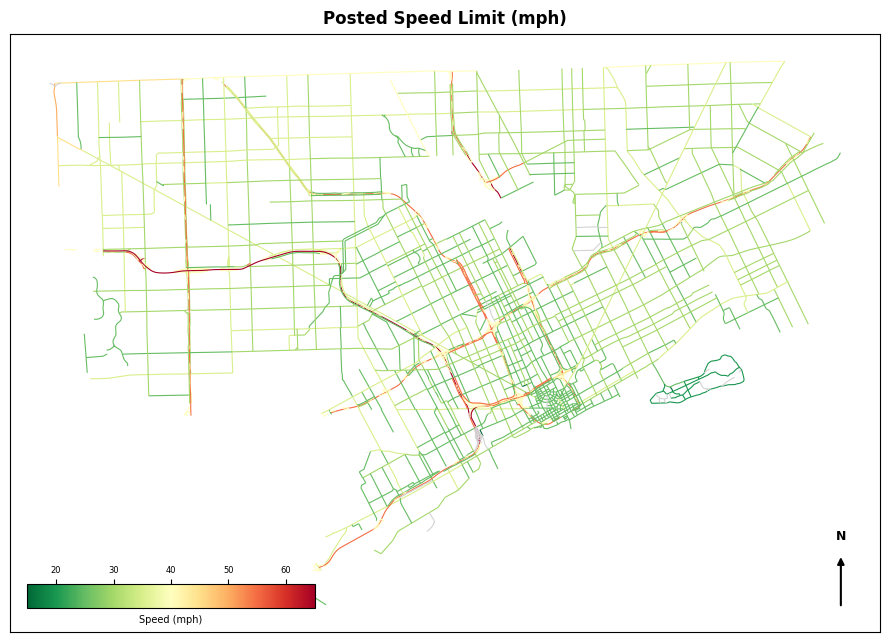

/var/folders/5z/7y4fq24d761794_v8h19r9xh0000gn/T/ipykernel_5081/1211379652.py:68: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  palette = plt.cm.get_cmap("tab10", len(categories))


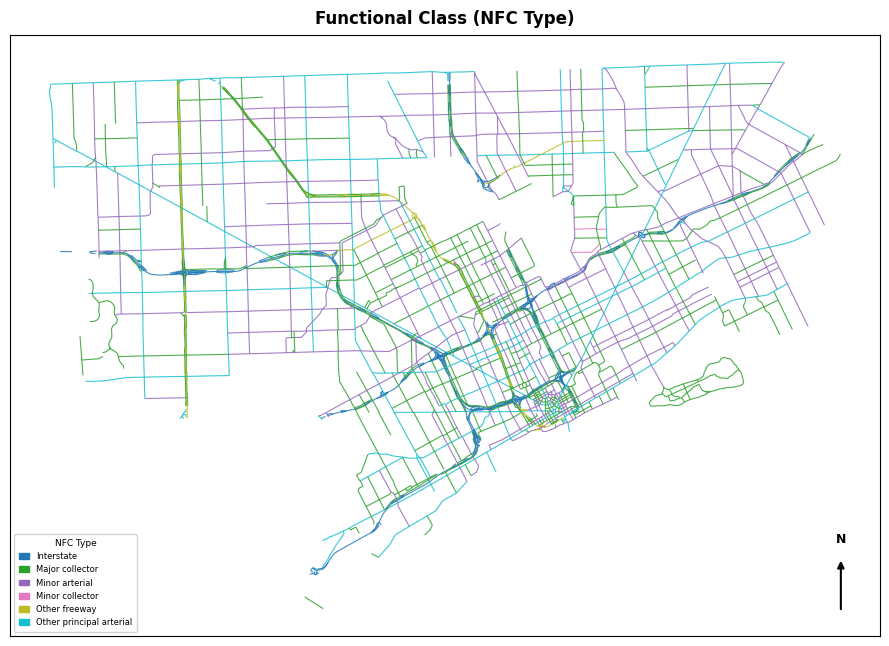

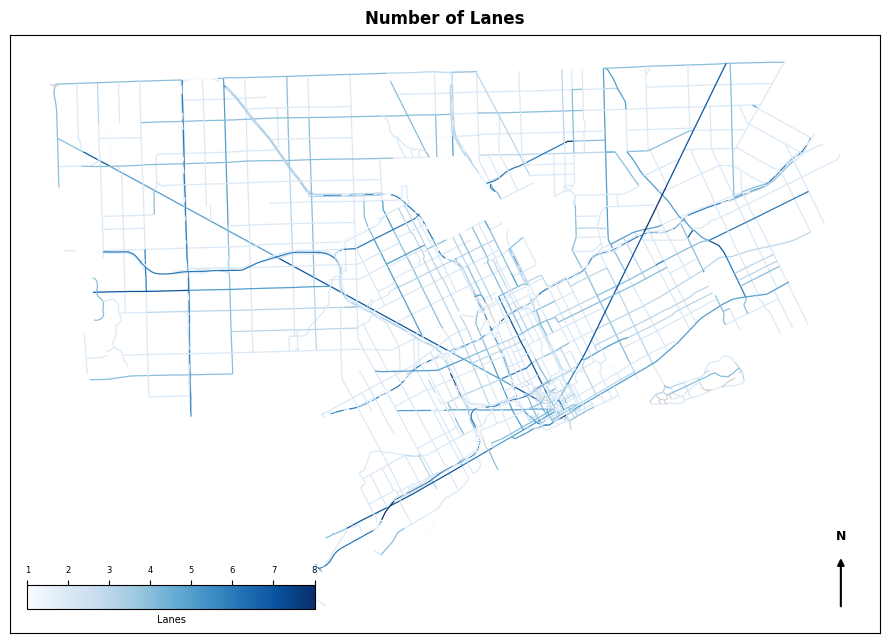

Saved → map_aadt.png  map_speed.png  map_nfc.png  map_lanes.png


In [ ]:
gdf_plot = gdf.copy()
gdf_plot["posted_speed_num"] = pd.to_numeric(gdf_plot["posted_speed"], errors="coerce")

FIG_W, FIG_H = 9, 7

def add_north_arrow(ax):
    """North arrow — bottom-right."""
    ax.annotate("", xy=(0.955, 0.13), xytext=(0.955, 0.04),
                xycoords="axes fraction",
                arrowprops=dict(arrowstyle="-|>", color="black", lw=1.5))
    ax.text(0.955, 0.15, "N", transform=ax.transAxes,
            ha="center", va="bottom", fontsize=9, fontweight="bold")

def add_colorbar(ax, cmap, vmin, vmax, label):
    """Inset colorbar — 1/3 plot width, bottom-left."""
    cax = ax.inset_axes([0.02, 0.04, 0.33, 0.04])
    norm = mcolors.Normalize(vmin=vmin, vmax=vmax)
    cb = ColorbarBase(cax, cmap=plt.get_cmap(cmap), norm=norm,
                      orientation="horizontal")
    cb.set_label(label, fontsize=7)
    cb.ax.tick_params(labelsize=6, which="both", bottom=False, labelbottom=False,
                      top=True, labeltop=True)

def style_ax(ax, title):
    ax.set_title(title, fontsize=12, fontweight="bold", pad=8)
    for spine in ax.spines.values():
        spine.set_visible(True)
        spine.set_linewidth(0.8)
    ax.set_xticks([])
    ax.set_yticks([])

# ── 1. AADT ──────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(FIG_W, FIG_H))
vmax_aadt = gdf_plot["num_aadt"].quantile(0.95)
gdf_plot.plot(ax=ax, column="num_aadt", cmap="YlOrRd",
              linewidth=0.8, vmin=0, vmax=vmax_aadt, legend=False)
style_ax(ax, "Annual Average Daily Traffic (AADT)")
add_colorbar(ax, "YlOrRd", 0, int(vmax_aadt), "AADT")
add_north_arrow(ax)
plt.tight_layout()
plt.savefig("map_aadt.png", dpi=150, bbox_inches="tight")
plt.show()

# ── 2. Posted Speed ──────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(FIG_W, FIG_H))
vmin_spd = gdf_plot["posted_speed_num"].min()
vmax_spd = gdf_plot["posted_speed_num"].max()
gdf_plot.plot(ax=ax, column="posted_speed_num", cmap="RdYlGn_r",
              linewidth=0.8, legend=False,
              missing_kwds={"color": "lightgrey"})
style_ax(ax, "Posted Speed Limit (mph)")
add_colorbar(ax, "RdYlGn_r", vmin_spd, vmax_spd, "Speed (mph)")
add_north_arrow(ax)
plt.tight_layout()
plt.savefig("map_speed.png", dpi=150, bbox_inches="tight")
plt.show()

# ── 3. NFC Type (categorical) — use gdf.plot() so aspect matches other maps ──
fig, ax = plt.subplots(figsize=(FIG_W, FIG_H))
categories = sorted(gdf_plot["nfc_name"].dropna().unique())
palette = plt.cm.get_cmap("tab10", len(categories))
cat_colors = {c: palette(i) for i, c in enumerate(categories)}

gdf_plot.plot(ax=ax, column="nfc_name", categorical=True,
              cmap="tab10", linewidth=0.8, alpha=0.85, legend=False)

patches = [mpatches.Patch(color=cat_colors[c], label=c) for c in categories]
ax.legend(handles=patches, fontsize=6, loc="lower left",
          framealpha=0.85, title="NFC Type", title_fontsize=6.5,
          borderpad=0.6, handlelength=1.2,
          bbox_to_anchor=(0.0, 0.0))
style_ax(ax, "Functional Class (NFC Type)")
add_north_arrow(ax)
plt.tight_layout()
plt.savefig("map_nfc.png", dpi=150, bbox_inches="tight")
plt.show()

# ── 4. Number of Lanes ───────────────────────────────────────────────────────
# NOTE: swap column="num_lanes" → column="ahf_per_m2" once you add:
#   gdf_plot["ahf_per_m2"] = gdf_plot["ahf_total"] / gdf_plot["road_area_m2"]
fig, ax = plt.subplots(figsize=(FIG_W, FIG_H))
vmin_ln = gdf_plot["num_lanes"].min()
vmax_ln = gdf_plot["num_lanes"].max()
gdf_plot.plot(ax=ax, column="num_lanes", cmap="Blues",
              linewidth=0.9, legend=False,
              missing_kwds={"color": "lightgrey"})
style_ax(ax, "Number of Lanes")
add_colorbar(ax, "Blues", vmin_ln, vmax_ln, "Lanes")
add_north_arrow(ax)
plt.tight_layout()
plt.savefig("map_lanes.png", dpi=150, bbox_inches="tight")
plt.show()

print("Saved → map_aadt.png  map_speed.png  map_nfc.png  map_lanes.png")

In [ ]:
import zipfile, io
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
import matplotlib.lines as mlines
from shapely.geometry import LineString
from shapely.ops import unary_union

# ── Load GTFS ────────────────────────────────────────────────────────────────
with zipfile.ZipFile("ddot_gtfs.zip") as z:
    stops  = pd.read_csv(io.BytesIO(z.read("stops.txt")))
    shapes = pd.read_csv(io.BytesIO(z.read("shapes.txt")))

# ── Build unique route shapes, then dissolve into one geometry ───────────────
shape_lines = (
    shapes.sort_values("shape_pt_sequence")
          .groupby("shape_id")
          .apply(lambda d: LineString(zip(d["shape_pt_lon"], d["shape_pt_lat"])))
)
# Merge all corridors into a single MultiLineString so each segment is drawn once
merged = unary_union(shape_lines.values)
corridor_gdf = gpd.GeoDataFrame(geometry=[merged], crs="EPSG:4326")

# ── Bus stops as points ───────────────────────────────────────────────────────
stops_gdf = gpd.GeoDataFrame(
    stops,
    geometry=gpd.points_from_xy(stops["stop_lon"], stops["stop_lat"]),
    crs="EPSG:4326"
)

# ── Plot ──────────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(11, 8))

corridor_gdf.plot(ax=ax, color="#004851", linewidth=1.0)
stops_gdf.plot(ax=ax, color="black", markersize=2, zorder=3)

ax.set_title("DDOT Bus Corridors & Stops — Detroit", fontsize=13, fontweight="bold", pad=10)
for spine in ax.spines.values():
    spine.set_visible(True)
    spine.set_linewidth(0.8)
ax.set_xticks([]); ax.set_yticks([])

corridor_line = mlines.Line2D([], [], color="#004851", linewidth=1.5, label="Bus corridor")
stop_dot      = mlines.Line2D([], [], marker="o", color="w", markerfacecolor="black",
                               markersize=4, label="Bus stop")
ax.legend(handles=[corridor_line, stop_dot], fontsize=8, loc="lower left",
          framealpha=0.9, borderpad=0.7, bbox_to_anchor=(0.0, 0.0))

ax.annotate("", xy=(0.955, 0.12), xytext=(0.955, 0.04),
            xycoords="axes fraction",
            arrowprops=dict(arrowstyle="-|>", color="black", lw=1.5))
ax.text(0.955, 0.14, "N", transform=ax.transAxes,
        ha="center", va="bottom", fontsize=9, fontweight="bold")

plt.tight_layout()
plt.savefig("map_bus_corridors.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved → map_bus_corridors.png")

In [ ]:
import zipfile, io
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from matplotlib.colorbar import ColorbarBase
from shapely.geometry import LineString

# ── Load GTFS ────────────────────────────────────────────────────────────────
with zipfile.ZipFile("ddot_gtfs.zip") as z:
    trips  = pd.read_csv(io.BytesIO(z.read("trips.txt")))
    shapes = pd.read_csv(io.BytesIO(z.read("shapes.txt")))

# ── Daily trip frequency per route ───────────────────────────────────────────
# Count total trips per route across all service days as a frequency proxy
route_freq = trips.groupby("route_id").size().reset_index(name="daily_trips")

# One representative shape per route (most-used shape_id)
shape_per_route = (trips.groupby(["route_id", "shape_id"])
                        .size().reset_index(name="n")
                        .sort_values("n", ascending=False)
                        .drop_duplicates("route_id")[["route_id", "shape_id"]])

route_freq = route_freq.merge(shape_per_route, on="route_id")

# ── Build shape geometries ────────────────────────────────────────────────────
shape_lines = (
    shapes.sort_values("shape_pt_sequence")
          .groupby("shape_id")
          .apply(lambda d: LineString(zip(d["shape_pt_lon"], d["shape_pt_lat"])))
          .reset_index()
          .rename(columns={0: "geometry"})
)
gdf_freq = gpd.GeoDataFrame(
    route_freq.merge(shape_lines, on="shape_id"),
    geometry="geometry", crs="EPSG:4326"
)

# ── Plot ──────────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(11, 8))

gdf_freq.plot(ax=ax, column="daily_trips", cmap="YlOrRd",
              linewidth=2.0, legend=False,
              vmin=gdf_freq["daily_trips"].min(),
              vmax=gdf_freq["daily_trips"].max())

ax.set_title("DDOT Bus Frequency — Daily Trips per Corridor", fontsize=13, fontweight="bold", pad=10)
for spine in ax.spines.values():
    spine.set_visible(True)
    spine.set_linewidth(0.8)
ax.set_xticks([]); ax.set_yticks([])

# Colorbar — bottom-left, 1/3 width
cax = ax.inset_axes([0.02, 0.10, 0.33, 0.04])
norm = mcolors.Normalize(vmin=gdf_freq["daily_trips"].min(),
                         vmax=gdf_freq["daily_trips"].max())
cb = ColorbarBase(cax, cmap=plt.get_cmap("YlOrRd"), norm=norm, orientation="horizontal")
cb.set_label("Daily trips", fontsize=7)
cb.ax.tick_params(labelsize=6, bottom=False, labelbottom=False, top=True, labeltop=True)

# North arrow — bottom-right
ax.annotate("", xy=(0.955, 0.12), xytext=(0.955, 0.04),
            xycoords="axes fraction",
            arrowprops=dict(arrowstyle="-|>", color="black", lw=1.5))
ax.text(0.955, 0.14, "N", transform=ax.transAxes,
        ha="center", va="bottom", fontsize=9, fontweight="bold")

plt.tight_layout()
plt.savefig("map_bus_frequency.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved → map_bus_frequency.png")

LST range: 10.9 – 65.0 °C  |  mean: 39.9 °C


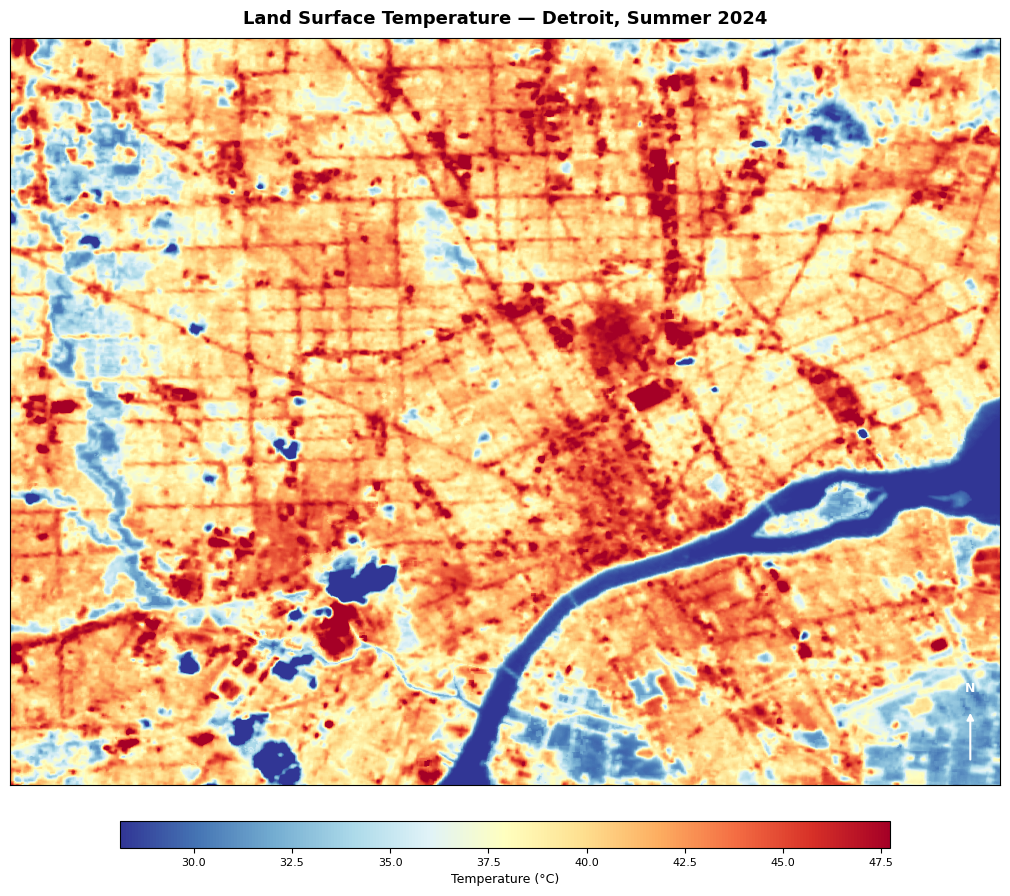

Saved → map_lst_summer2024.png


In [34]:
import rasterio
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from matplotlib.colorbar import ColorbarBase
import numpy as np

# ── Load LST raster ──────────────────────────────────────────────────────────
tif_path = "/Users/orwell/UHI-Detroit/data/detroit_lst_summer2024.tif"
with rasterio.open(tif_path) as src:
    lst = src.read(1, masked=True)
    extent = [src.bounds.left, src.bounds.right, src.bounds.bottom, src.bounds.top]

print(f"LST range: {lst.min():.1f} – {lst.max():.1f} °C  |  mean: {lst.mean():.1f} °C")

vmin = np.percentile(lst.compressed(), 2)
vmax = np.percentile(lst.compressed(), 98)

# ── Layout: map on top, colorbar strip below ──────────────────────────────────
fig = plt.figure(figsize=(11, 9))
ax     = fig.add_axes([0.05, 0.12, 0.90, 0.83])   # map: [left, bottom, width, height]
cax    = fig.add_axes([0.15, 0.05, 0.70, 0.03])   # colorbar: full-width strip below

ax.imshow(lst, cmap="RdYlBu_r", extent=extent,
          vmin=vmin, vmax=vmax, aspect="auto")

ax.set_title("Land Surface Temperature — Detroit, Summer 2024",
             fontsize=13, fontweight="bold", pad=10)
for spine in ax.spines.values():
    spine.set_visible(True)
    spine.set_linewidth(0.8)
ax.set_xticks([]); ax.set_yticks([])

# North arrow — bottom-right inside map
ax.annotate("", xy=(0.97, 0.10), xytext=(0.97, 0.03),
            xycoords="axes fraction",
            arrowprops=dict(arrowstyle="-|>", color="white", lw=1.5))
ax.text(0.97, 0.12, "N", transform=ax.transAxes,
        ha="center", va="bottom", fontsize=9, fontweight="bold", color="white")

# Colorbar — outside, below map
norm = mcolors.Normalize(vmin=vmin, vmax=vmax)
cb = ColorbarBase(cax, cmap=plt.get_cmap("RdYlBu_r"), norm=norm, orientation="horizontal")
cb.set_label("Temperature (°C)", fontsize=9)
cb.ax.tick_params(labelsize=8)

plt.savefig("map_lst_summer2024.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved → map_lst_summer2024.png")

In [ ]:
import rasterio
from rasterio.warp import calculate_default_transform, reproject, Resampling
import numpy as np
import geopandas as gpd
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from matplotlib.colorbar import ColorbarBase
from matplotlib.lines import Line2D

TIF_PATH = "/Users/orwell/UHI-Detroit/data/detroit_lst_summer2024.tif"
GEOJSON  = "yearly_traffic_volume_layers_2602944522563934822.geojson"
DST_CRS  = "EPSG:4326"

# ── Load traffic ──────────────────────────────────────────────────────────────
gdf_tr = gpd.read_file(GEOJSON)
gdf_tr["num_aadt"] = pd.to_numeric(gdf_tr["num_aadt"], errors="coerce")
tr_minx, tr_miny, tr_maxx, tr_maxy = gdf_tr.total_bounds

# ── Warp LST to EPSG:4326 ─────────────────────────────────────────────────────
with rasterio.open(TIF_PATH) as src:
    transform, width, height = calculate_default_transform(
        src.crs, DST_CRS, src.width, src.height, *src.bounds,
        dst_width=src.width, dst_height=src.height
    )
    lst_warped = np.full((height, width), np.nan, dtype=np.float32)
    reproject(
        source=rasterio.band(src, 1),
        destination=lst_warped,
        src_transform=src.transform, src_crs=src.crs,
        dst_transform=transform,     dst_crs=DST_CRS,
        resampling=Resampling.bilinear,
        src_nodata=src.nodata, dst_nodata=np.nan,
    )

r_left   = transform.c
r_top    = transform.f
r_right  = r_left  + transform.a * width
r_bottom = r_top   + transform.e * height

clip_minx = max(tr_minx, r_left);   clip_maxx = min(tr_maxx, r_right)
clip_miny = max(tr_miny, r_bottom); clip_maxy = min(tr_maxy, r_top)

lst_ma = np.ma.masked_invalid(lst_warped)
vmin_lst = np.nanpercentile(lst_warped[~np.isnan(lst_warped)], 2)
vmax_lst = np.nanpercentile(lst_warped[~np.isnan(lst_warped)], 98)

# ── Line width scaled to AADT ─────────────────────────────────────────────────
aadt_vals = gdf_tr["num_aadt"].dropna()
aadt_min, aadt_max = aadt_vals.quantile(0.05), aadt_vals.quantile(0.95)
LW_MIN, LW_MAX = 0.4, 4.5

def aadt_to_lw(aadt):
    t = np.clip((aadt - aadt_min) / (aadt_max - aadt_min), 0, 1)
    return LW_MIN + t * (LW_MAX - LW_MIN)

# ── Figure — full black background ───────────────────────────────────────────
fig = plt.figure(figsize=(12, 10), facecolor="black")
ax      = fig.add_axes([0.05, 0.13, 0.90, 0.83], facecolor="black")
cax_lst = fig.add_axes([0.05, 0.05, 0.45, 0.025])
ax_leg  = fig.add_axes([0.55, 0.01, 0.40, 0.08], facecolor="black")

# ── Map ───────────────────────────────────────────────────────────────────────
ax.imshow(lst_ma, cmap="RdYlBu_r",
          extent=[r_left, r_right, r_bottom, r_top],
          vmin=vmin_lst, vmax=vmax_lst,
          aspect="auto", origin="upper", interpolation="none")

for _, row in gdf_tr.iterrows():
    if row.geometry is None or row.geometry.is_empty:
        continue
    aadt = row["num_aadt"]
    if pd.isna(aadt):
        continue
    xs, ys = row.geometry.xy
    ax.plot(xs, ys, color="white", linewidth=aadt_to_lw(aadt),
            alpha=0.85, solid_capstyle="round")

ax.set_xlim(clip_minx, clip_maxx)
ax.set_ylim(clip_miny, clip_maxy)

title = ax.set_title("Land Surface Temperature & Traffic Density — Detroit, Summer 2024",
                     fontsize=12, fontweight="bold", pad=8)
title.set_color("white")

for spine in ax.spines.values():
    spine.set_edgecolor("white"); spine.set_linewidth(0.8)
ax.set_xticks([]); ax.set_yticks([])

ax.annotate("", xy=(0.97, 0.10), xytext=(0.97, 0.03), xycoords="axes fraction",
            arrowprops=dict(arrowstyle="-|>", color="white", lw=1.5))
ax.text(0.97, 0.12, "N", transform=ax.transAxes,
        ha="center", va="bottom", fontsize=9, fontweight="bold", color="white")

# ── LST colorbar ──────────────────────────────────────────────────────────────
norm_lst = mcolors.Normalize(vmin=vmin_lst, vmax=vmax_lst)
cb1 = ColorbarBase(cax_lst, cmap=plt.get_cmap("RdYlBu_r"),
                   norm=norm_lst, orientation="horizontal")
cb1.set_label("LST (°C)", fontsize=8, color="white")
cb1.ax.tick_params(labelsize=7, colors="white")
cb1.ax.xaxis.set_tick_params(color="white")
plt.setp(cb1.ax.xaxis.get_ticklabels(), color="white")
cb1.outline.set_edgecolor("white")

# ── AADT legend ───────────────────────────────────────────────────────────────
ax_leg.set_xticks([]); ax_leg.set_yticks([])
for spine in ax_leg.spines.values():
    spine.set_edgecolor("white"); spine.set_linewidth(0.8)

legend_aadts = [10_000, 50_000, 120_000]
handles = [
    Line2D([0], [0], color="white", linewidth=aadt_to_lw(v),
           label=f"{v:,}", solid_capstyle="round")
    for v in legend_aadts
]
leg = ax_leg.legend(handles=handles, title="AADT", fontsize=7.5,
                    title_fontsize=8, loc="center", ncol=3,
                    frameon=False, labelcolor="white",
                    borderpad=0.5, handlelength=2.5, columnspacing=1.2)
leg.get_title().set_color("white")

plt.savefig("map_lst_traffic_overlay.png", dpi=200, bbox_inches="tight",
            facecolor=fig.get_facecolor())
plt.show()
print("Saved → map_lst_traffic_overlay.png")